# 08 — Results

`pipeline/s60_analysis.py` builds every result table (95% percentile bootstrap intervals over articles, 1,000 resamples) and `results.json`; `pipeline/s70_figures.py` draws the figures; `pipeline/s80_deck.py` builds the slide deck from the same files, so every number in the deck and README comes from here.

Research questions:

1. Which industries does AI news say AI is affecting?
2. In which direction, and through which mechanisms?
3. What conditions do adoption stories associate with success or setbacks?

In [1]:
import os, sys

PROJECT_DIR = "/content/drive/MyDrive/NLP/NLP_FINAL_PROJECT_Tom_Chen"
IN_COLAB = os.path.isdir("/content")
if IN_COLAB and not os.path.isdir("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount("/content/drive")
os.environ.setdefault("PROJECT_DIR", PROJECT_DIR)
# Path to a checkout of this repository (on Drive in Colab).
sys.path.insert(0, os.environ.get("REPO_DIR", f"{os.environ['PROJECT_DIR']}/code"))

import json
import pandas as pd
from pipeline import config

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

In [2]:
RUN = False  # set True to rebuild tables, figures and the deck (CPU, ~2 min)
if RUN:
    from pipeline import s60_analysis, s70_figures, s80_deck
    s60_analysis.main(); s70_figures.main(); s80_deck.main()

from IPython.display import Image, display
fig = lambda name, w=780: display(Image(filename=str(config.out("figures", name)), width=w))
table = lambda name: pd.read_csv(config.out("tables", name))
res = json.load(open(config.out("results.json")))

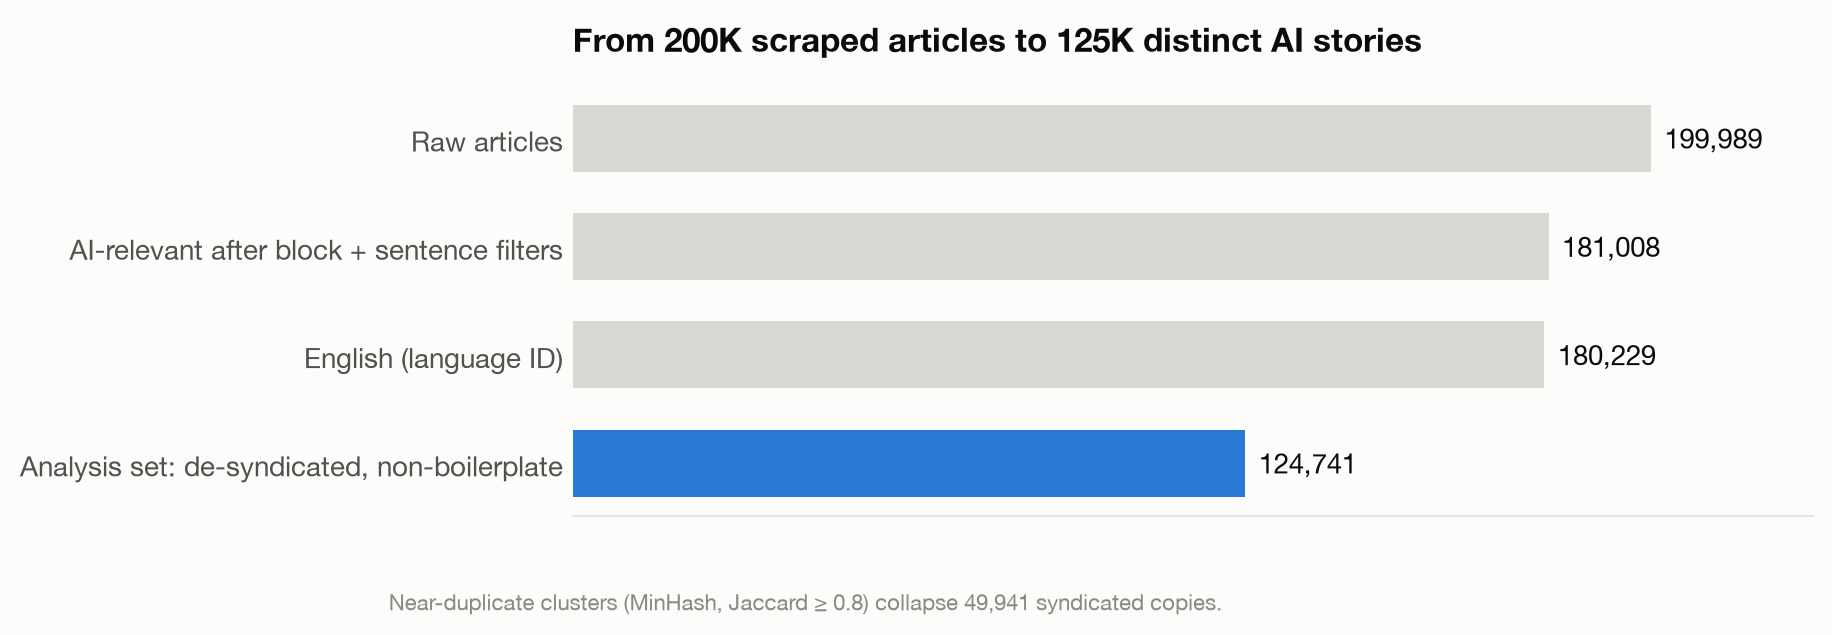

In [3]:
fig("f01_corpus_funnel.png")

## RQ1 — Which industries

Shares come from the LLM-labeled random sample. About half of AI news discusses software & IT and a tenth semiconductors & hardware (the AI supply side); the chart shows sectors adopting AI.

In [4]:
expo = table("industry_exposure.csv")
expo[["industry", "supply_side", "n_docs_sample", "share_any", "share_any_lo", "share_any_hi", "share_primary",
      "share_any_excl_press"]].round(3)

,industry,supply_side,n_docs_sample,share_any,share_any_lo,share_any_hi,share_primary,share_any_excl_press
0,software_it,True,7453,0.497,0.489,0.504,0.352,0.492
1,media_entertainment,False,2469,0.165,0.159,0.171,0.112,0.173
2,none,False,2058,0.137,0.132,0.143,0.137,0.148
3,semiconductors_hardware,True,1572,0.105,0.100,0.110,0.060,0.108
4,government_defense,False,1330,0.089,0.084,0.093,0.057,0.090
5,healthcare_life_sciences,False,1161,0.077,0.073,0.082,0.066,0.068
6,finance_insurance,False,934,0.062,0.059,0.066,0.045,0.058
7,education,False,882,0.059,0.055,0.063,0.046,0.058
8,retail_consumer,False,703,0.047,0.043,0.050,0.035,0.044
9,legal_professional,False,514,0.034,0.031,0.037,0.020,0.032


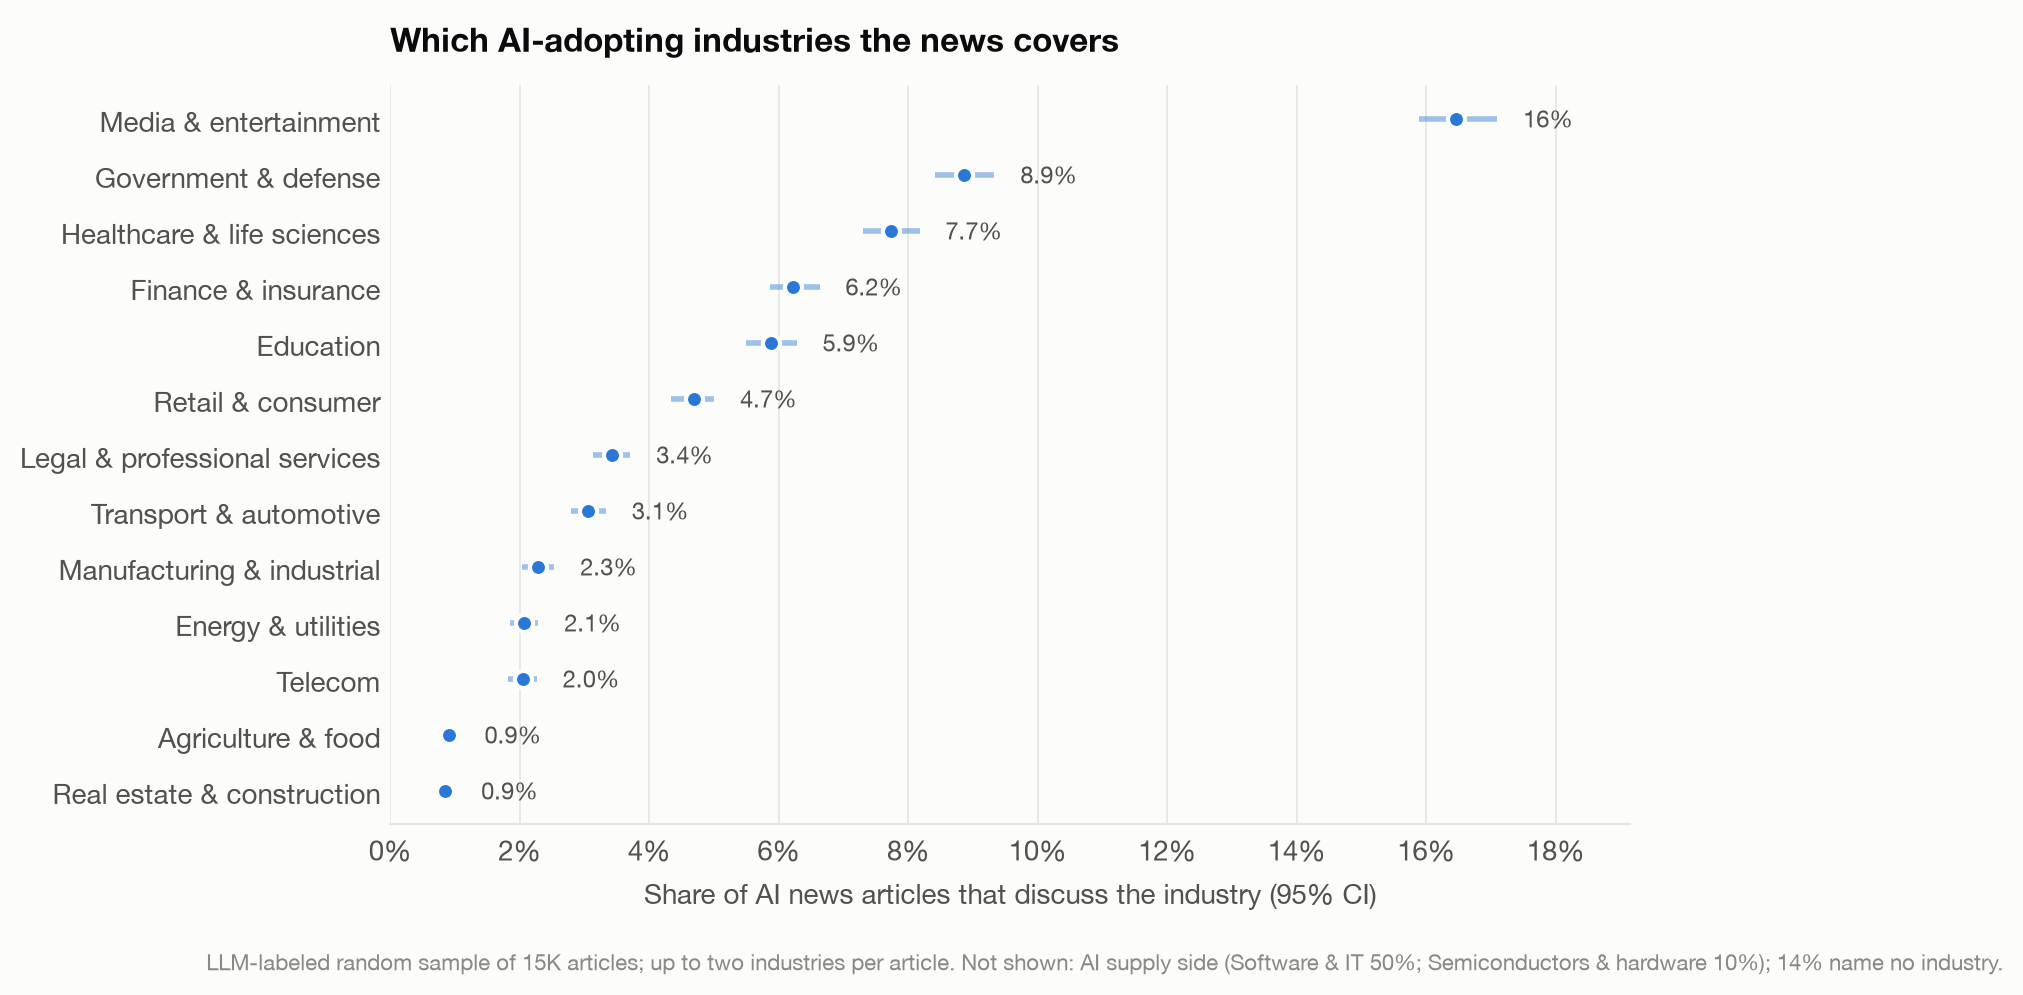

In [5]:
fig("f02_industry_exposure.png")

Change in each industry's share of all articles, before ChatGPT (to 2022-11-30) vs. the last 12 months, using the classifier-assigned full corpus.

In [6]:
table("industry_share_change.csv").round(3)

,industry,share_pre_chatgpt,share_last_12m,change_pp,change_pp_lo,change_pp_hi
0,software_it,0.451,0.598,14.693,13.475,15.892
1,semiconductors_hardware,0.085,0.160,7.455,6.744,8.219
2,media_entertainment,0.131,0.160,2.855,2.011,3.704
3,finance_insurance,0.044,0.051,0.648,0.109,1.158
4,government_defense,0.063,0.069,0.631,0.062,1.252
5,telecom,0.029,0.031,0.130,-0.280,0.545
6,legal_professional,0.022,0.022,0.034,-0.327,0.366
7,energy_utilities,0.033,0.032,-0.098,-0.501,0.314
8,real_estate_construction,0.016,0.012,-0.380,-0.687,-0.094
9,agriculture_food,0.014,0.005,-0.849,-1.129,-0.585


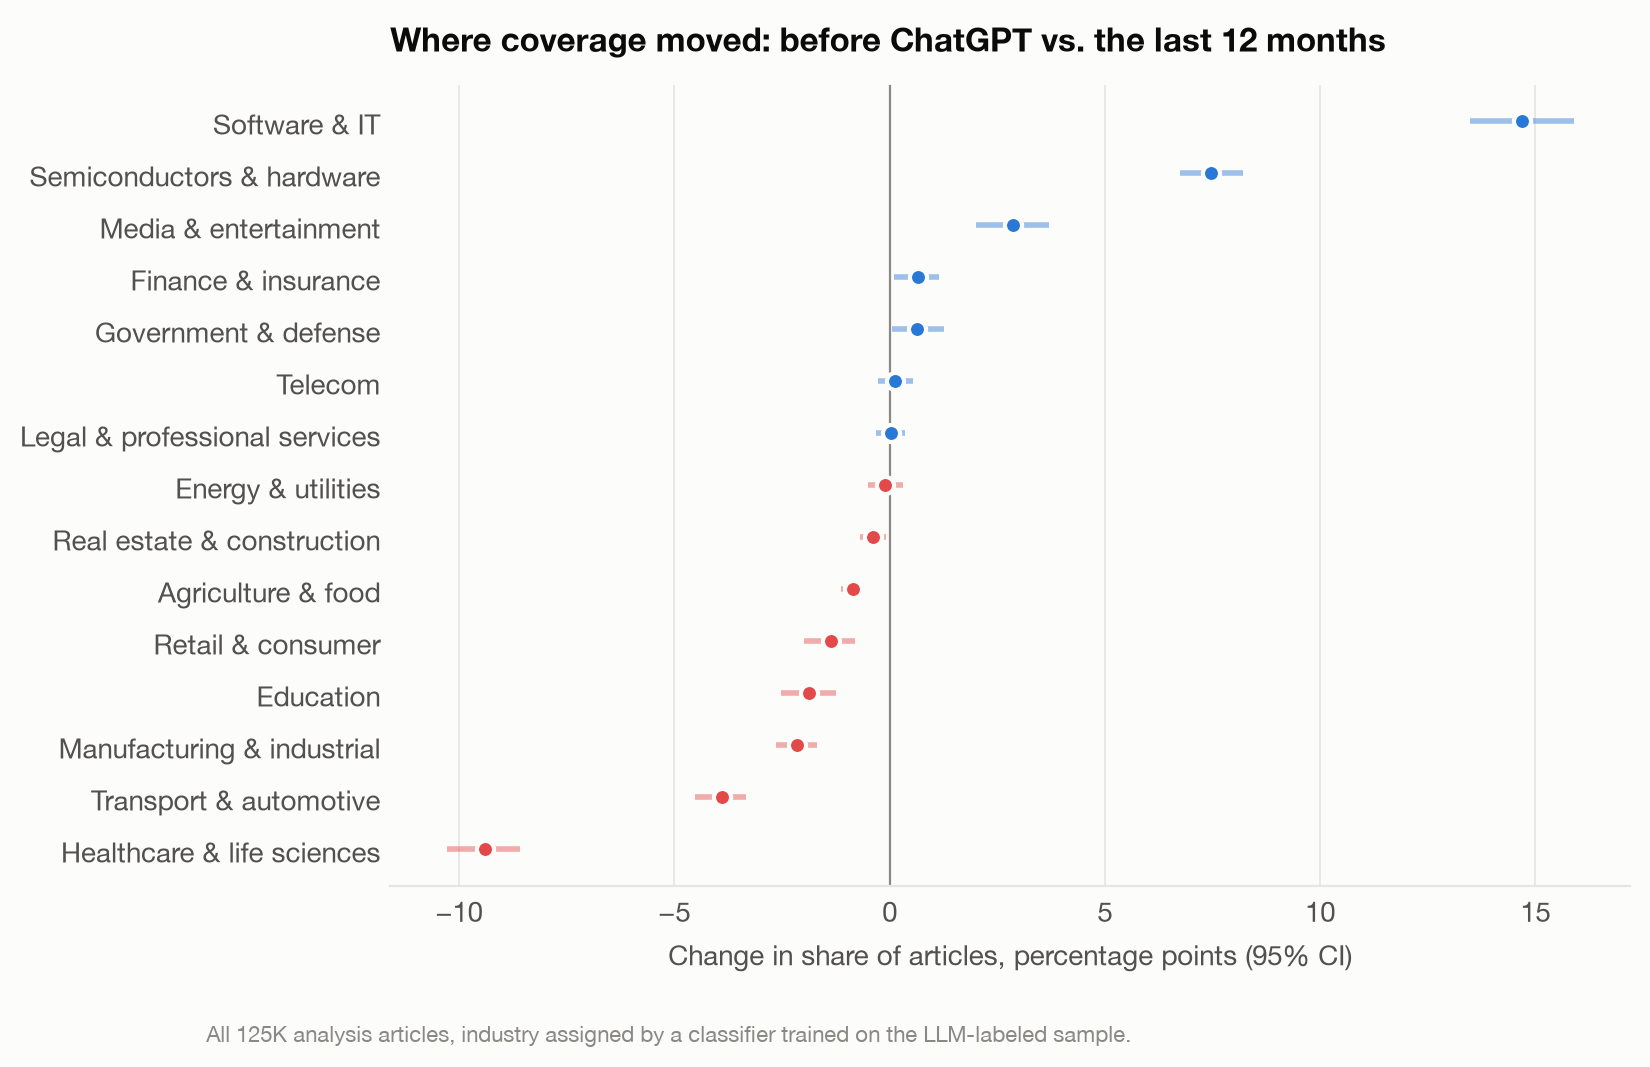

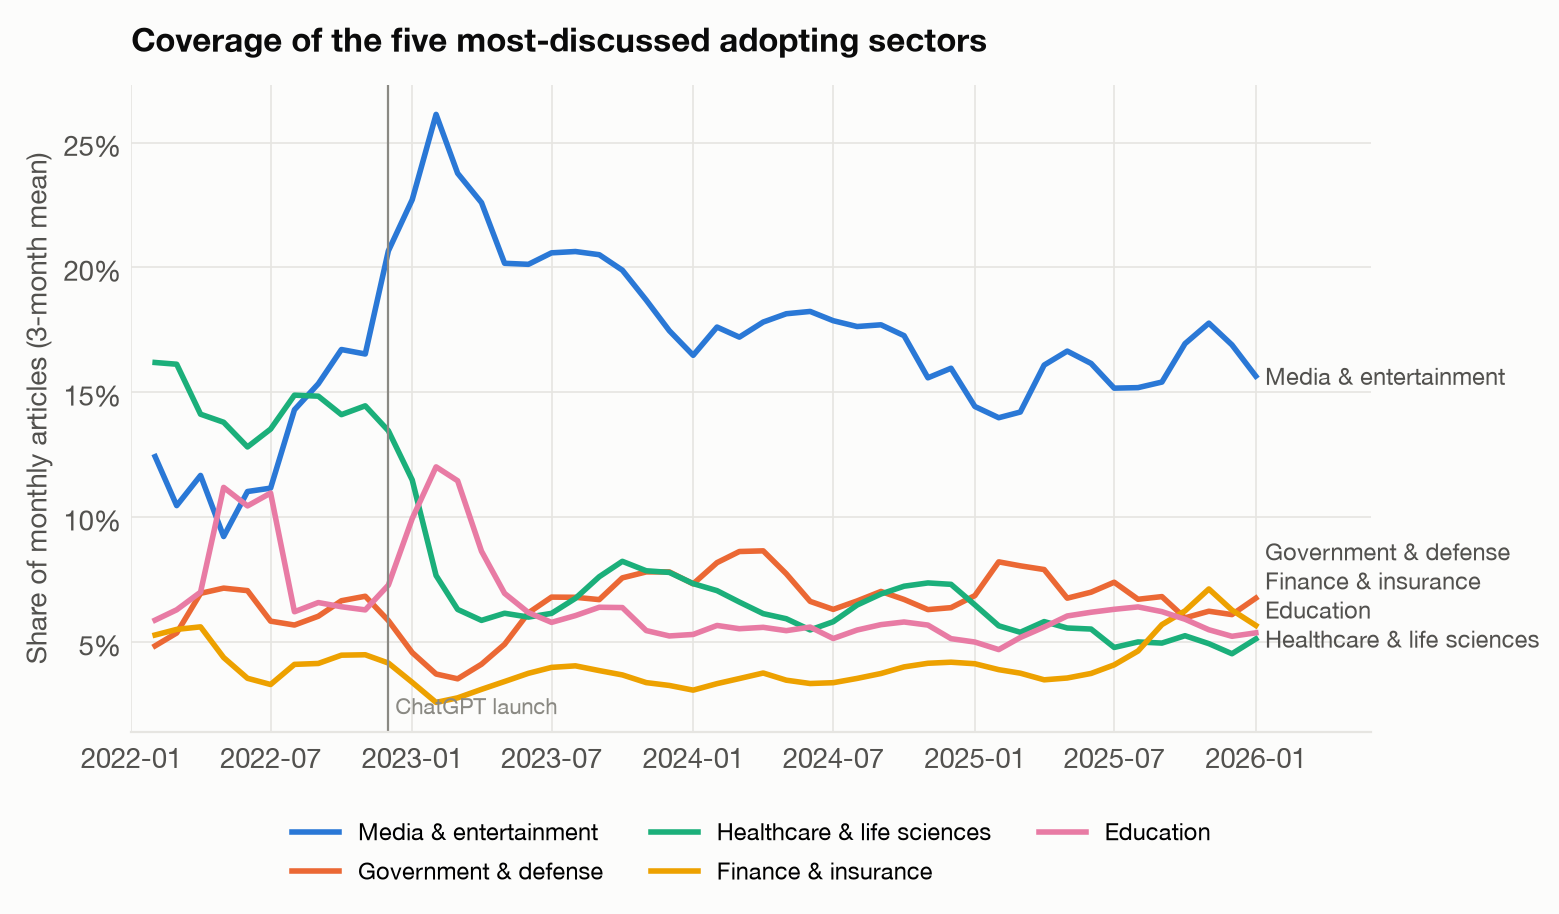

In [7]:
fig("f03_industry_change.png"); fig("f04_industry_trend.png")

## RQ2 — Direction and mechanism

Article framing (LLM) and entity-level sentiment (06C classifier) are measured independently; their rank correlation across industries is reported below.

In [8]:
direction = table("industry_direction.csv")
print("Spearman rho, LLM net framing vs. entity sentiment index:",
      round(direction[["net_direction", "entity_sentiment_index"]].corr("spearman").iloc[0, 1], 3))
direction[["industry", "n_docs_sample", "share_positive", "share_negative", "net_direction", "net_direction_lo",
           "net_direction_hi", "entity_sentiment_index"]].round(3)

Spearman rho, LLM net framing vs. entity sentiment index: 0.962


,industry,n_docs_sample,share_positive,share_negative,net_direction,net_direction_lo,net_direction_hi,entity_sentiment_index
0,manufacturing_industrial,183,0.896,0.011,0.885,0.831,0.933,0.652
1,healthcare_life_sciences,996,0.822,0.030,0.792,0.763,0.823,0.547
2,telecom,166,0.813,0.048,0.765,0.681,0.838,0.572
3,retail_consumer,518,0.743,0.042,0.701,0.654,0.748,0.571
4,transportation_automotive,325,0.729,0.043,0.686,0.629,0.744,0.485
5,semiconductors_hardware,893,0.750,0.071,0.680,0.640,0.718,0.460
6,energy_utilities,201,0.706,0.090,0.617,0.519,0.706,0.503
7,finance_insurance,678,0.634,0.072,0.562,0.514,0.606,0.432
8,software_it,5277,0.575,0.083,0.492,0.475,0.509,0.372
9,education,694,0.575,0.091,0.484,0.432,0.531,0.374


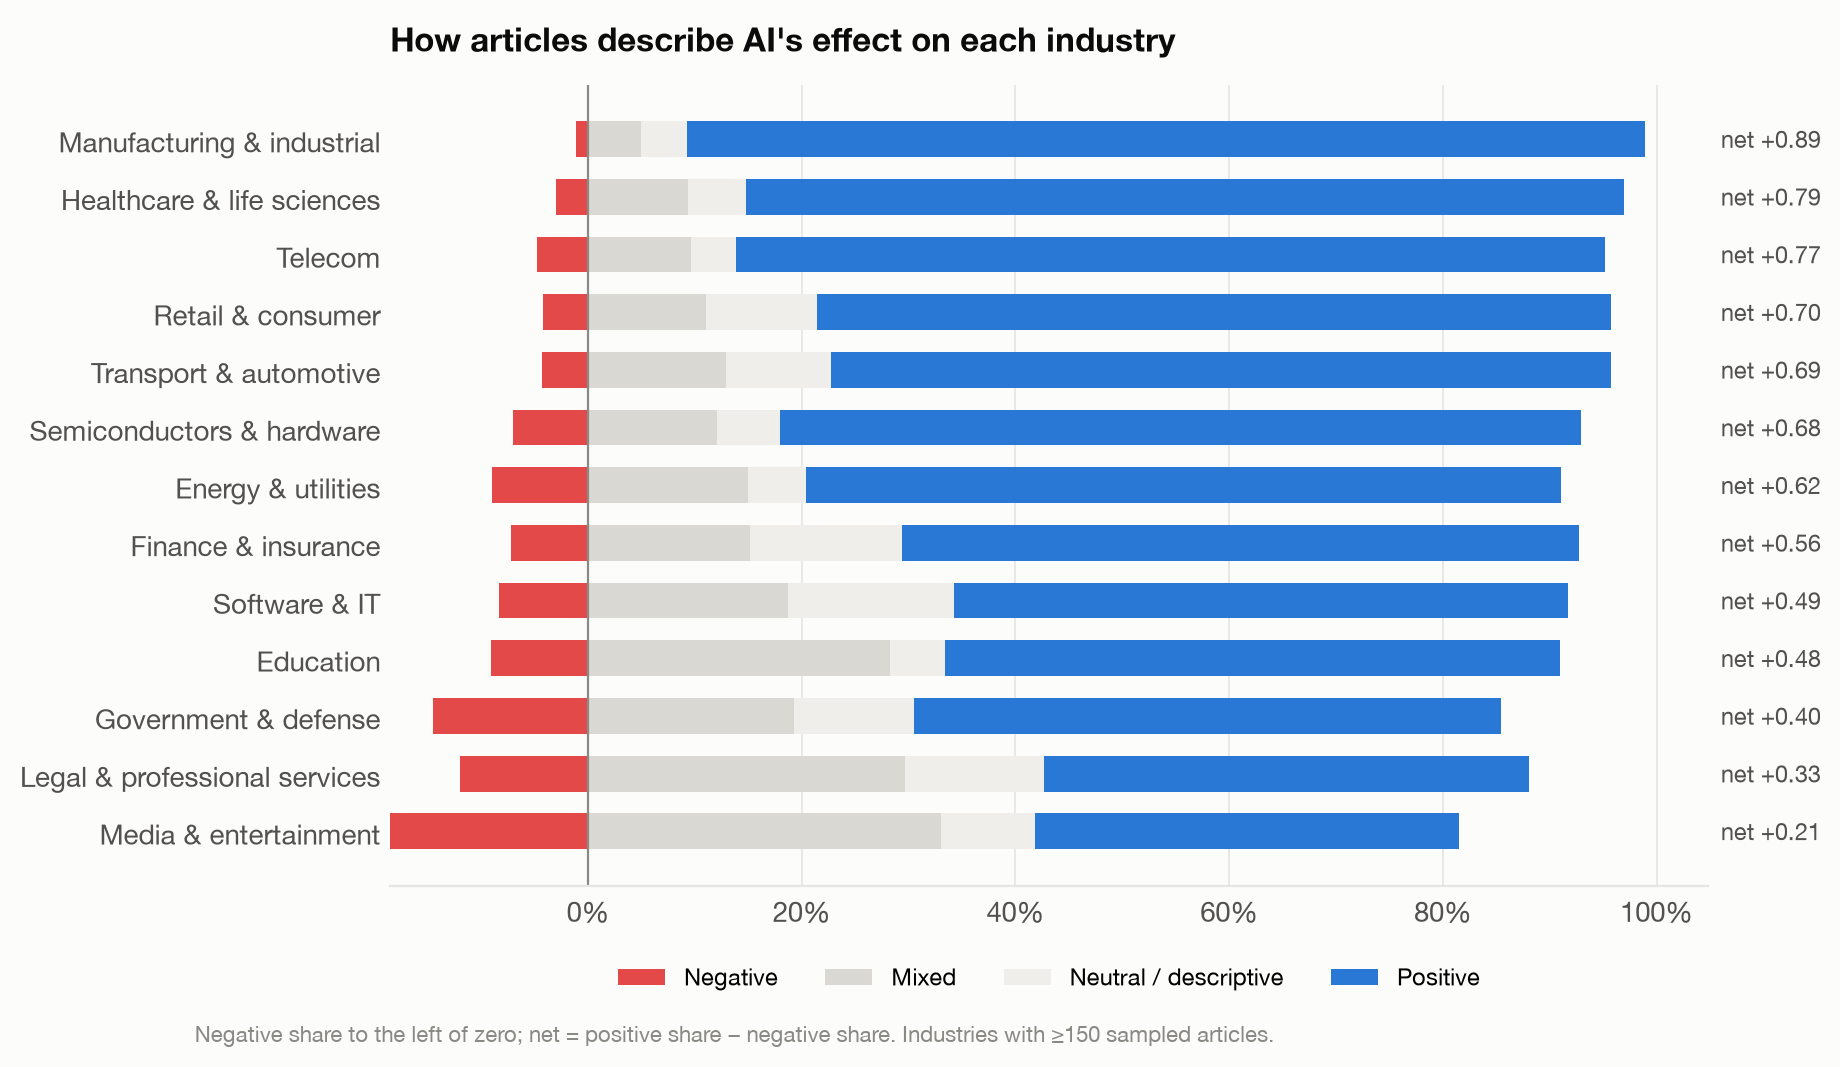

In [9]:
fig("f05_direction_by_industry.png")

In [10]:
mech = table("industry_mechanisms.csv")
mech[["industry", "n_docs_sample"] + [c for c in mech.columns if c.startswith("share_") and not c.endswith(("_lo", "_hi"))]].round(3)

,industry,n_docs_sample,share_automation,share_augmentation,share_cost_efficiency,share_new_offerings,share_workflow_redesign
0,software_it,5277,0.179,0.231,0.133,0.517,0.154
1,semiconductors_hardware,893,0.026,0.053,0.256,0.600,0.044
2,telecom,166,0.337,0.247,0.253,0.590,0.422
3,finance_insurance,678,0.453,0.379,0.189,0.366,0.202
4,healthcare_life_sciences,996,0.267,0.590,0.180,0.434,0.254
5,education,694,0.219,0.491,0.026,0.245,0.265
6,media_entertainment,1680,0.343,0.273,0.070,0.473,0.104
7,retail_consumer,518,0.342,0.367,0.174,0.598,0.176
8,manufacturing_industrial,183,0.601,0.377,0.279,0.464,0.328
9,transportation_automotive,325,0.363,0.360,0.228,0.443,0.249


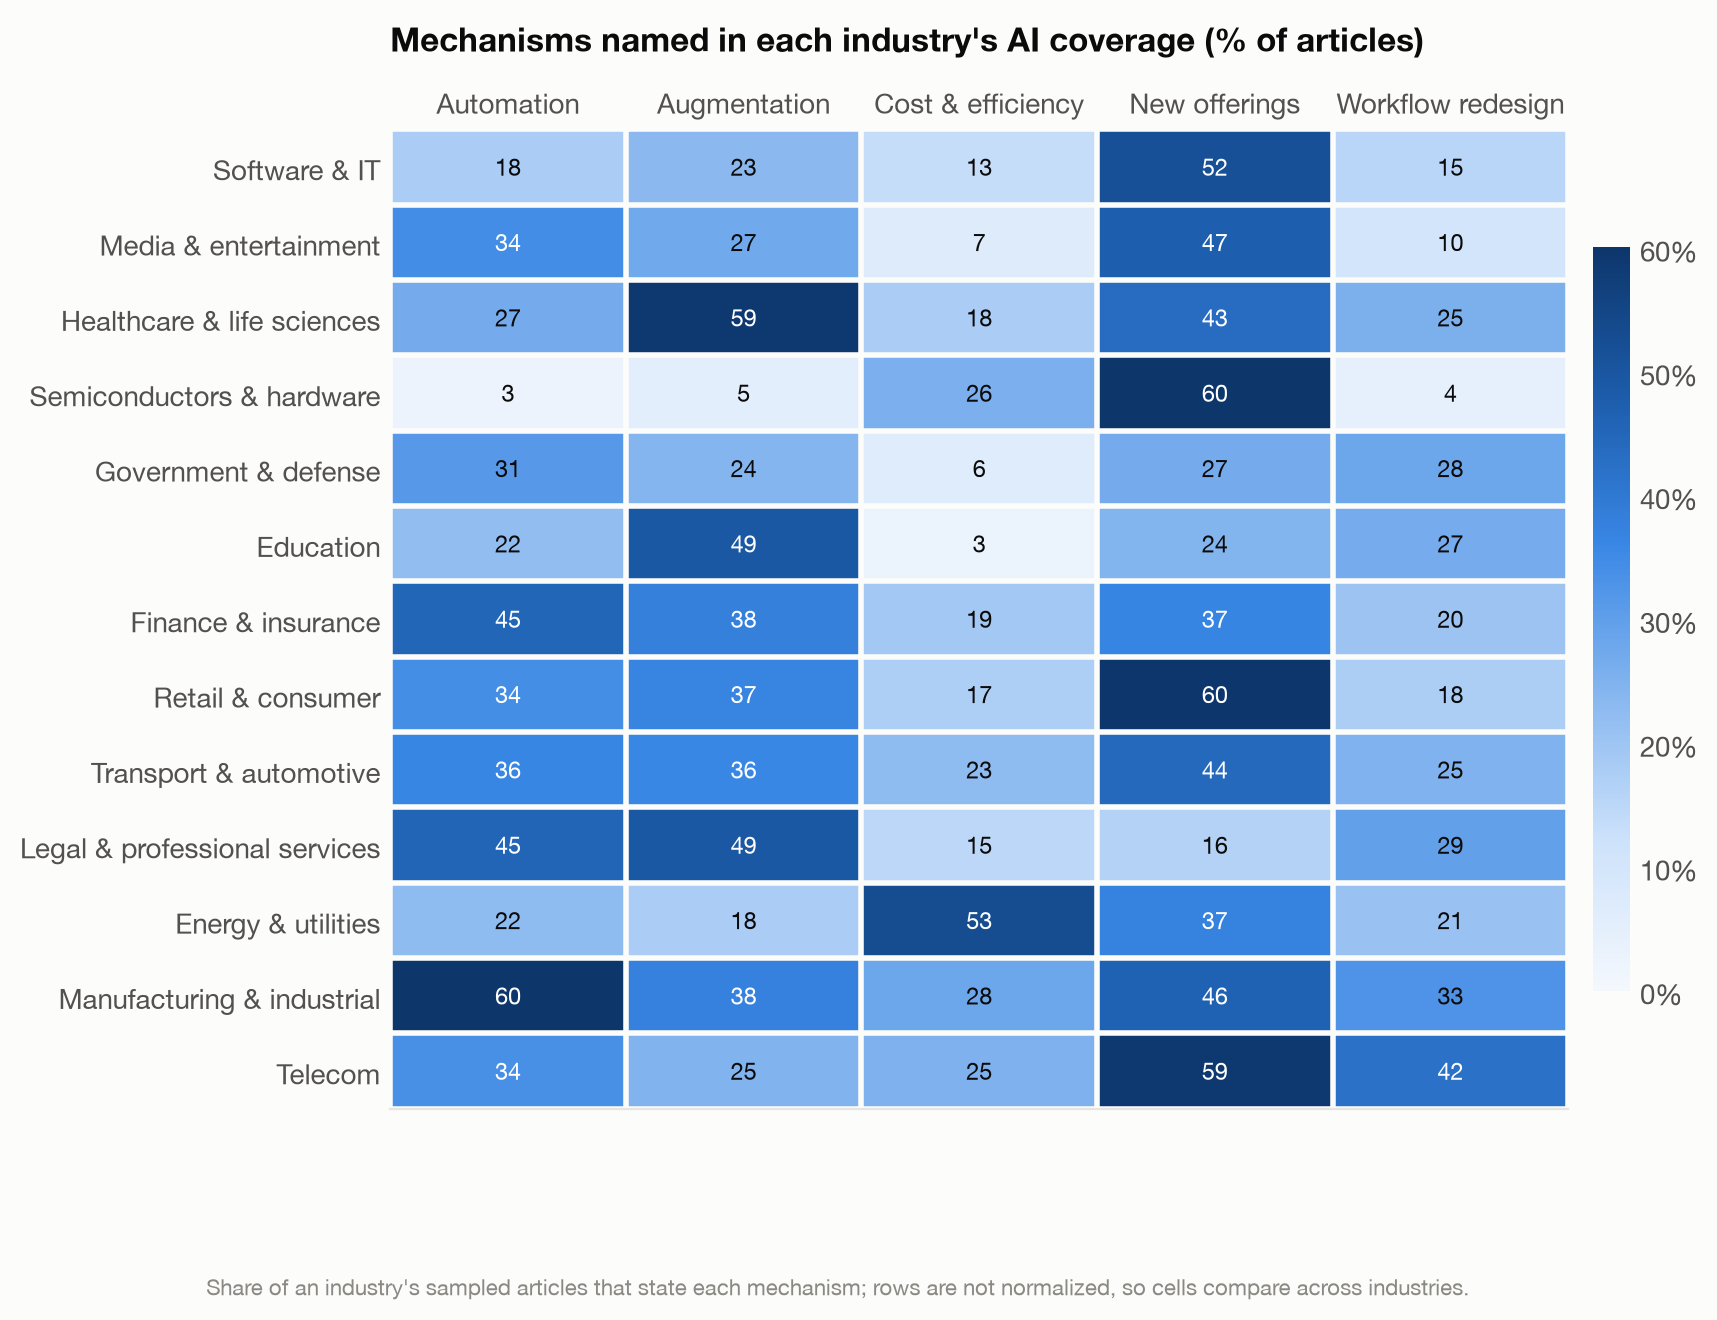

In [11]:
fig("f06_mechanism_heatmap.png")

Entity sentiment: named entities with at least 100 scored articles; index = mean over articles of P(positive) − P(negative).

In [12]:
ents = table("entity_sentiment.csv")
named = ents[ents.kind == "named"]
for t in ["company", "technology", "government_institution", "person"]:
    print(t); print(named[named.type == t].head(10)[["name", "n_docs_scored", "sentiment_index", "sentiment_index_lo",
                                                     "sentiment_index_hi", "sentiment_index_excl_press"]].round(3).to_string(index=False), "\n")

company
     name  n_docs_scored  sentiment_index  sentiment_index_lo  sentiment_index_hi  sentiment_index_excl_press
   OpenAI           2819            0.110               0.085               0.135                       0.104
   Google           2822            0.127               0.105               0.150                       0.122
Microsoft           2788            0.210               0.188               0.234                       0.199
   Nvidia           2588            0.347               0.321               0.374                       0.333
     Meta           2605            0.119               0.096               0.145                       0.112
    Apple           2476            0.144               0.120               0.166                       0.142
   Amazon           2562            0.186               0.166               0.206                       0.175
Anthropic           2263            0.184               0.158               0.211                       0.174
  

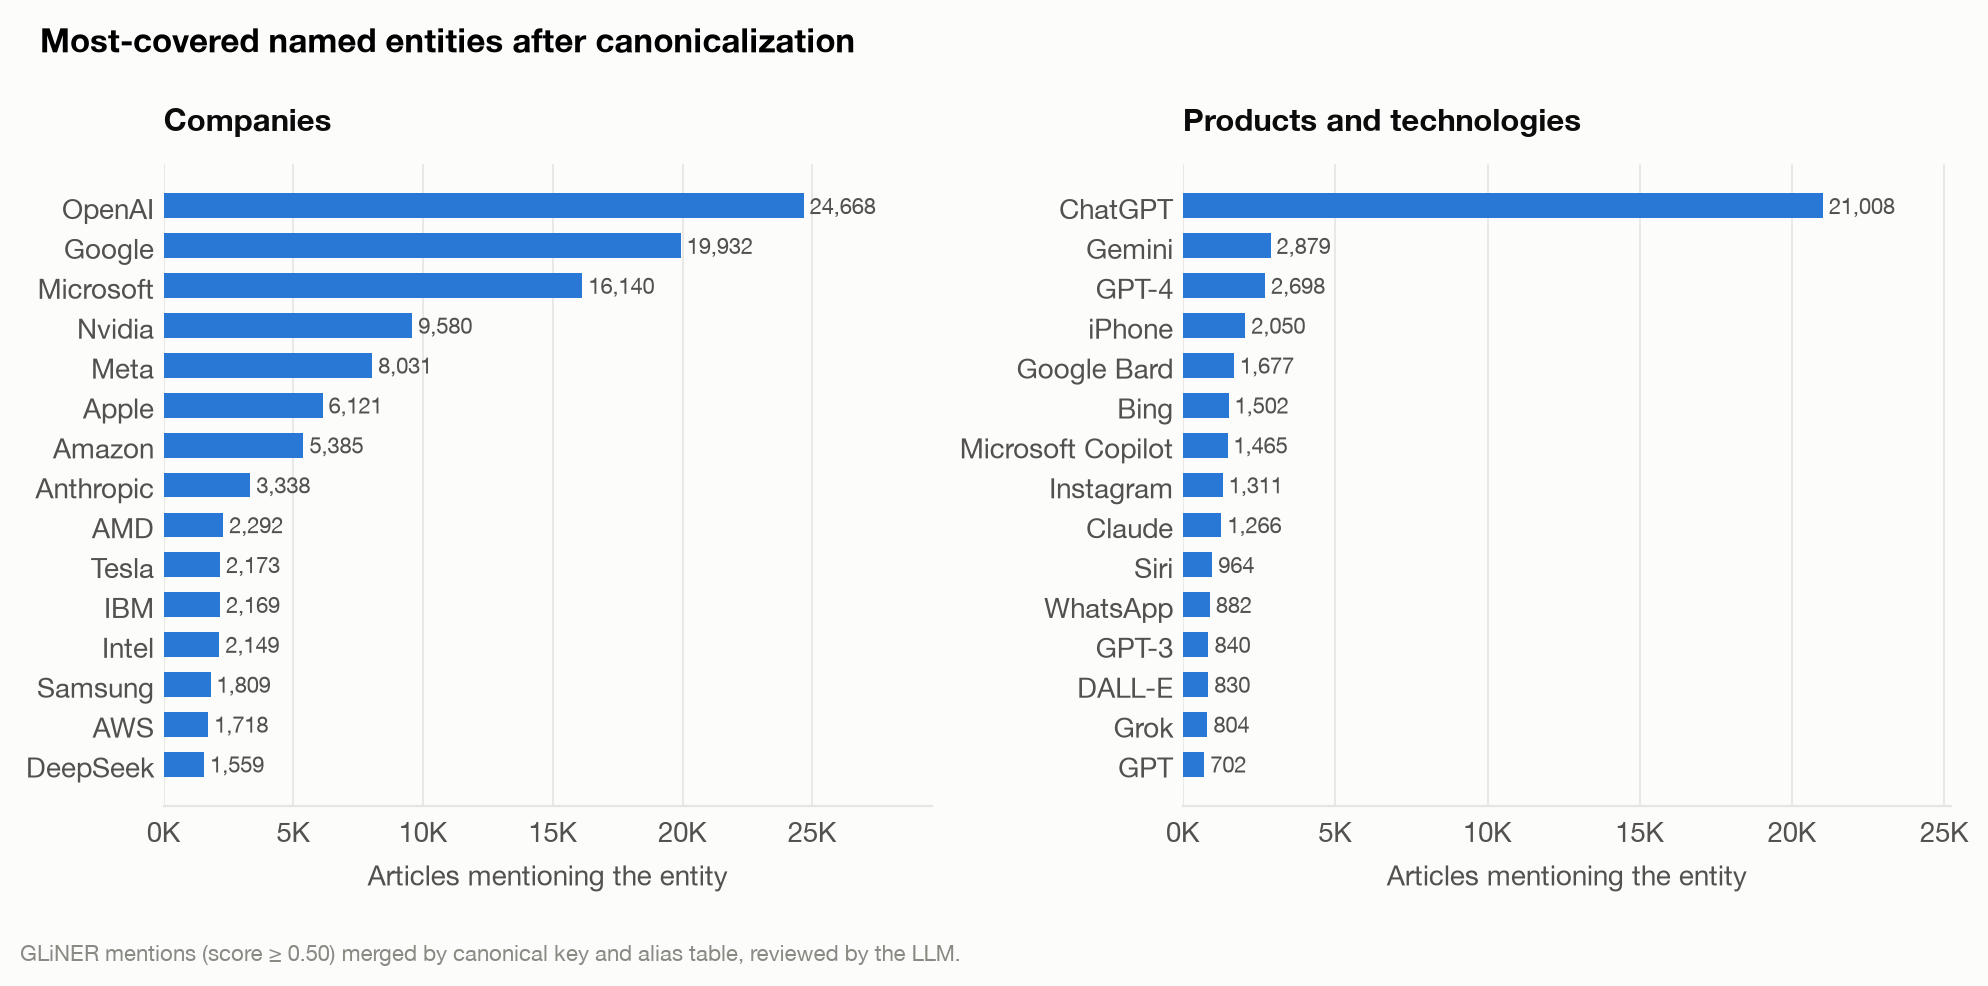

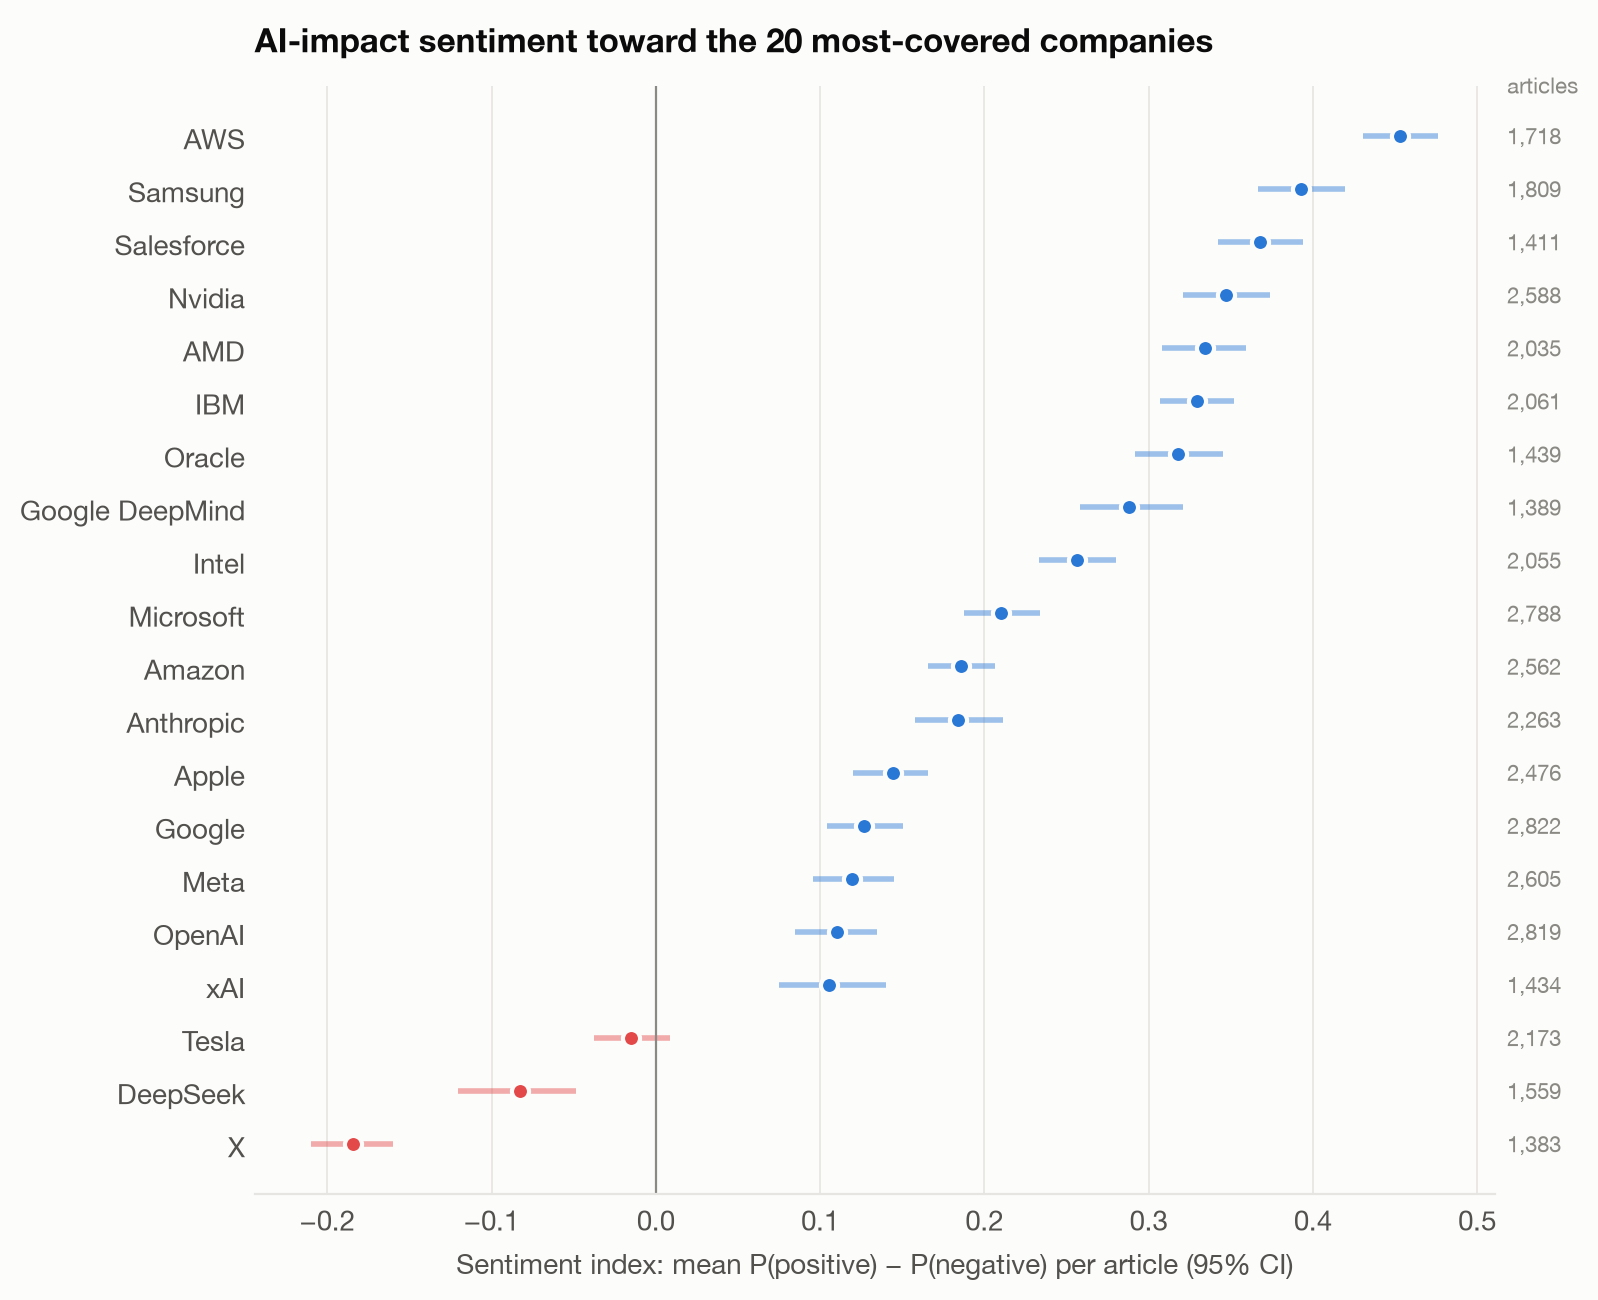

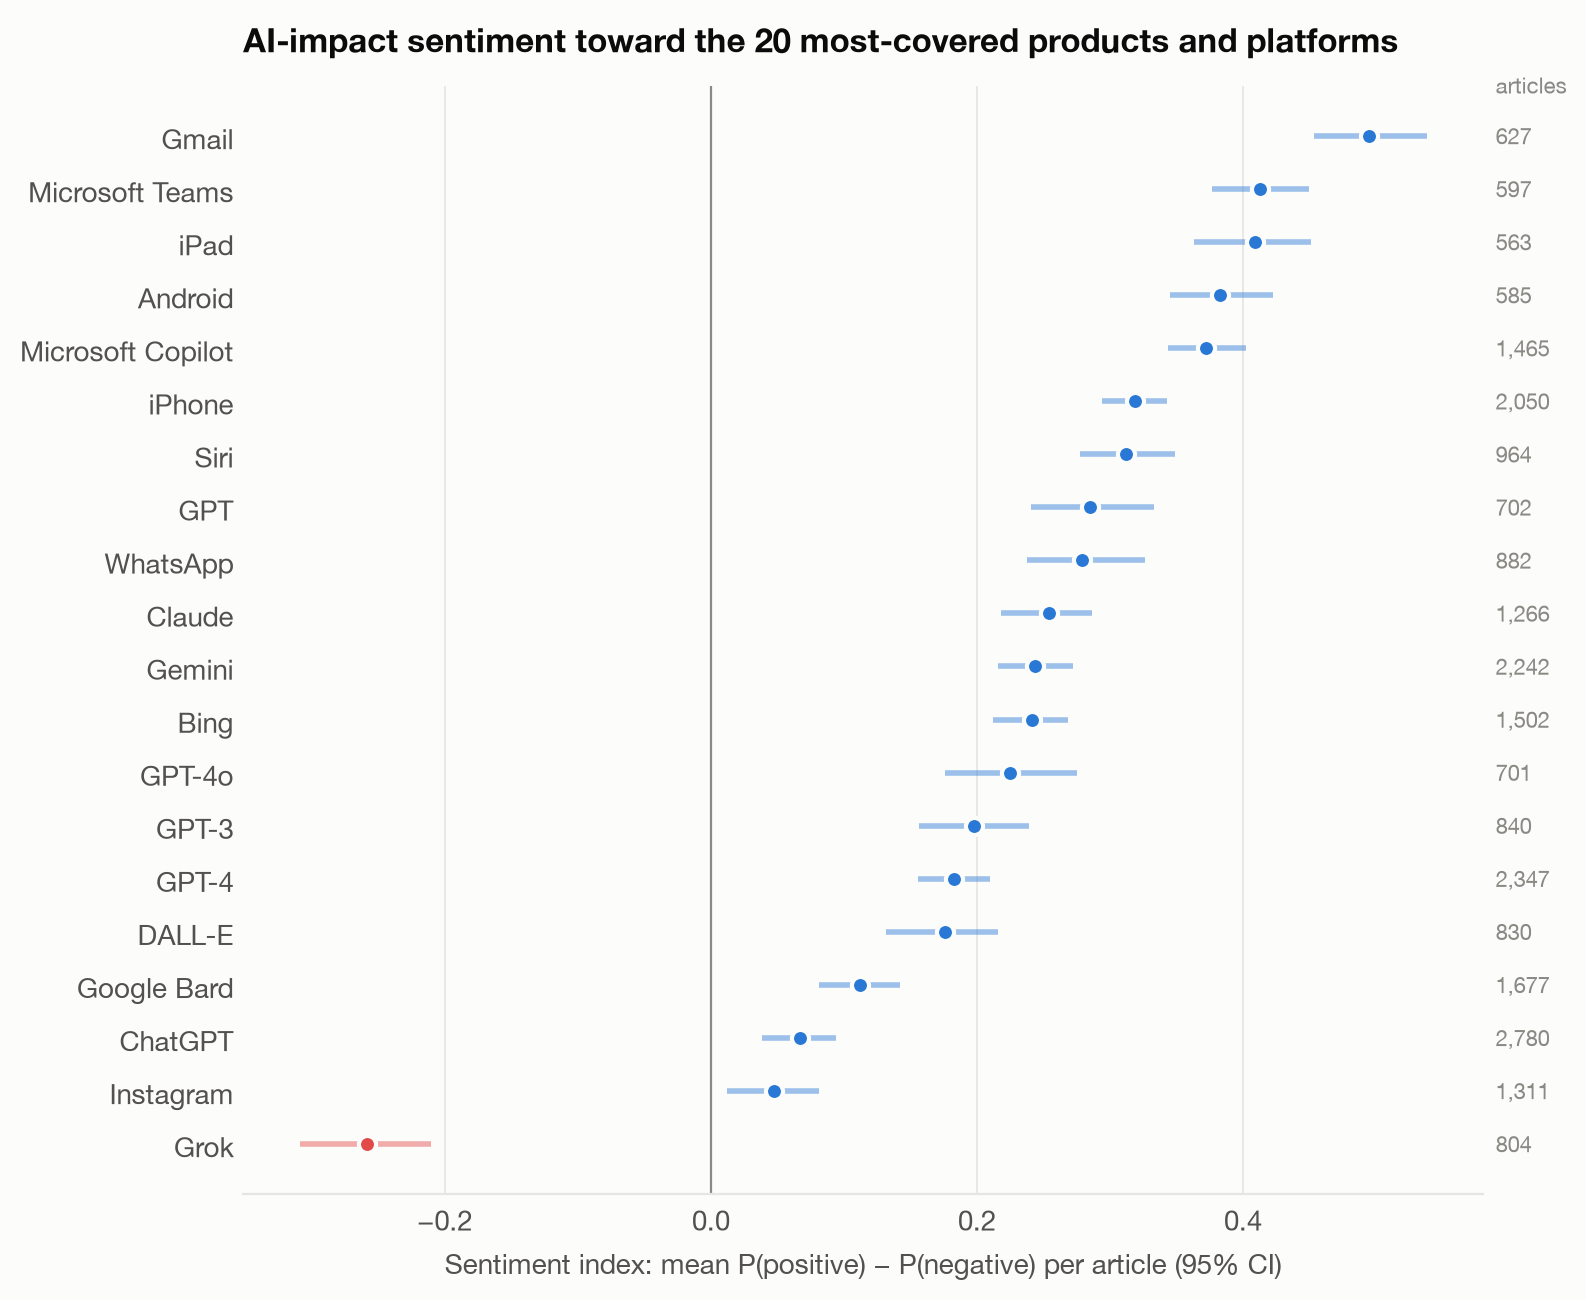

In [13]:
fig("f16_entity_coverage.png", 900); fig("f07_entity_sentiment_companies.png"); fig("f08_entity_sentiment_technologies.png")

Topic-level sentiment: entity sentiment of mentions inside each topic's paragraphs, averaged per article (topics with ≥ 200 scored articles).

In [14]:
ts = table("topic_sentiment.csv")
ts = ts[ts.is_coherent]
pd.concat([ts.head(8), ts.tail(8)])[["label", "industry", "n_docs_scored", "sentiment_index", "sentiment_index_lo",
                                     "sentiment_index_hi", "share_negative"]].round(3)

,label,industry,n_docs_scored,sentiment_index,sentiment_index_lo,sentiment_index_hi,share_negative
0,AI-Enabled Cybercrime,government_defense,1190,-0.582,-0.615,-0.548,0.723
1,OpenAI FTC Investigation,software_it,1151,-0.542,-0.569,-0.515,0.600
2,AI election misinformation,government_defense,3631,-0.525,-0.542,-0.509,0.611
3,AI Copyright Infringement Lawsuits,legal_professional,2618,-0.268,-0.293,-0.243,0.453
4,AI Chatbot Safety for Teens,none,2206,-0.221,-0.248,-0.193,0.429
5,AI in Journalism,media_entertainment,842,-0.131,-0.175,-0.083,0.370
6,Chinese AI chipmakers,semiconductors_hardware,1458,-0.123,-0.155,-0.092,0.381
7,Elon Musk's Grok Chatbot,software_it,701,-0.116,-0.166,-0.064,0.394
70,Battery and Energy Materials,energy_utilities,448,0.646,0.618,0.673,0.014
71,AI PC Hardware,semiconductors_hardware,3420,0.652,0.643,0.663,0.030


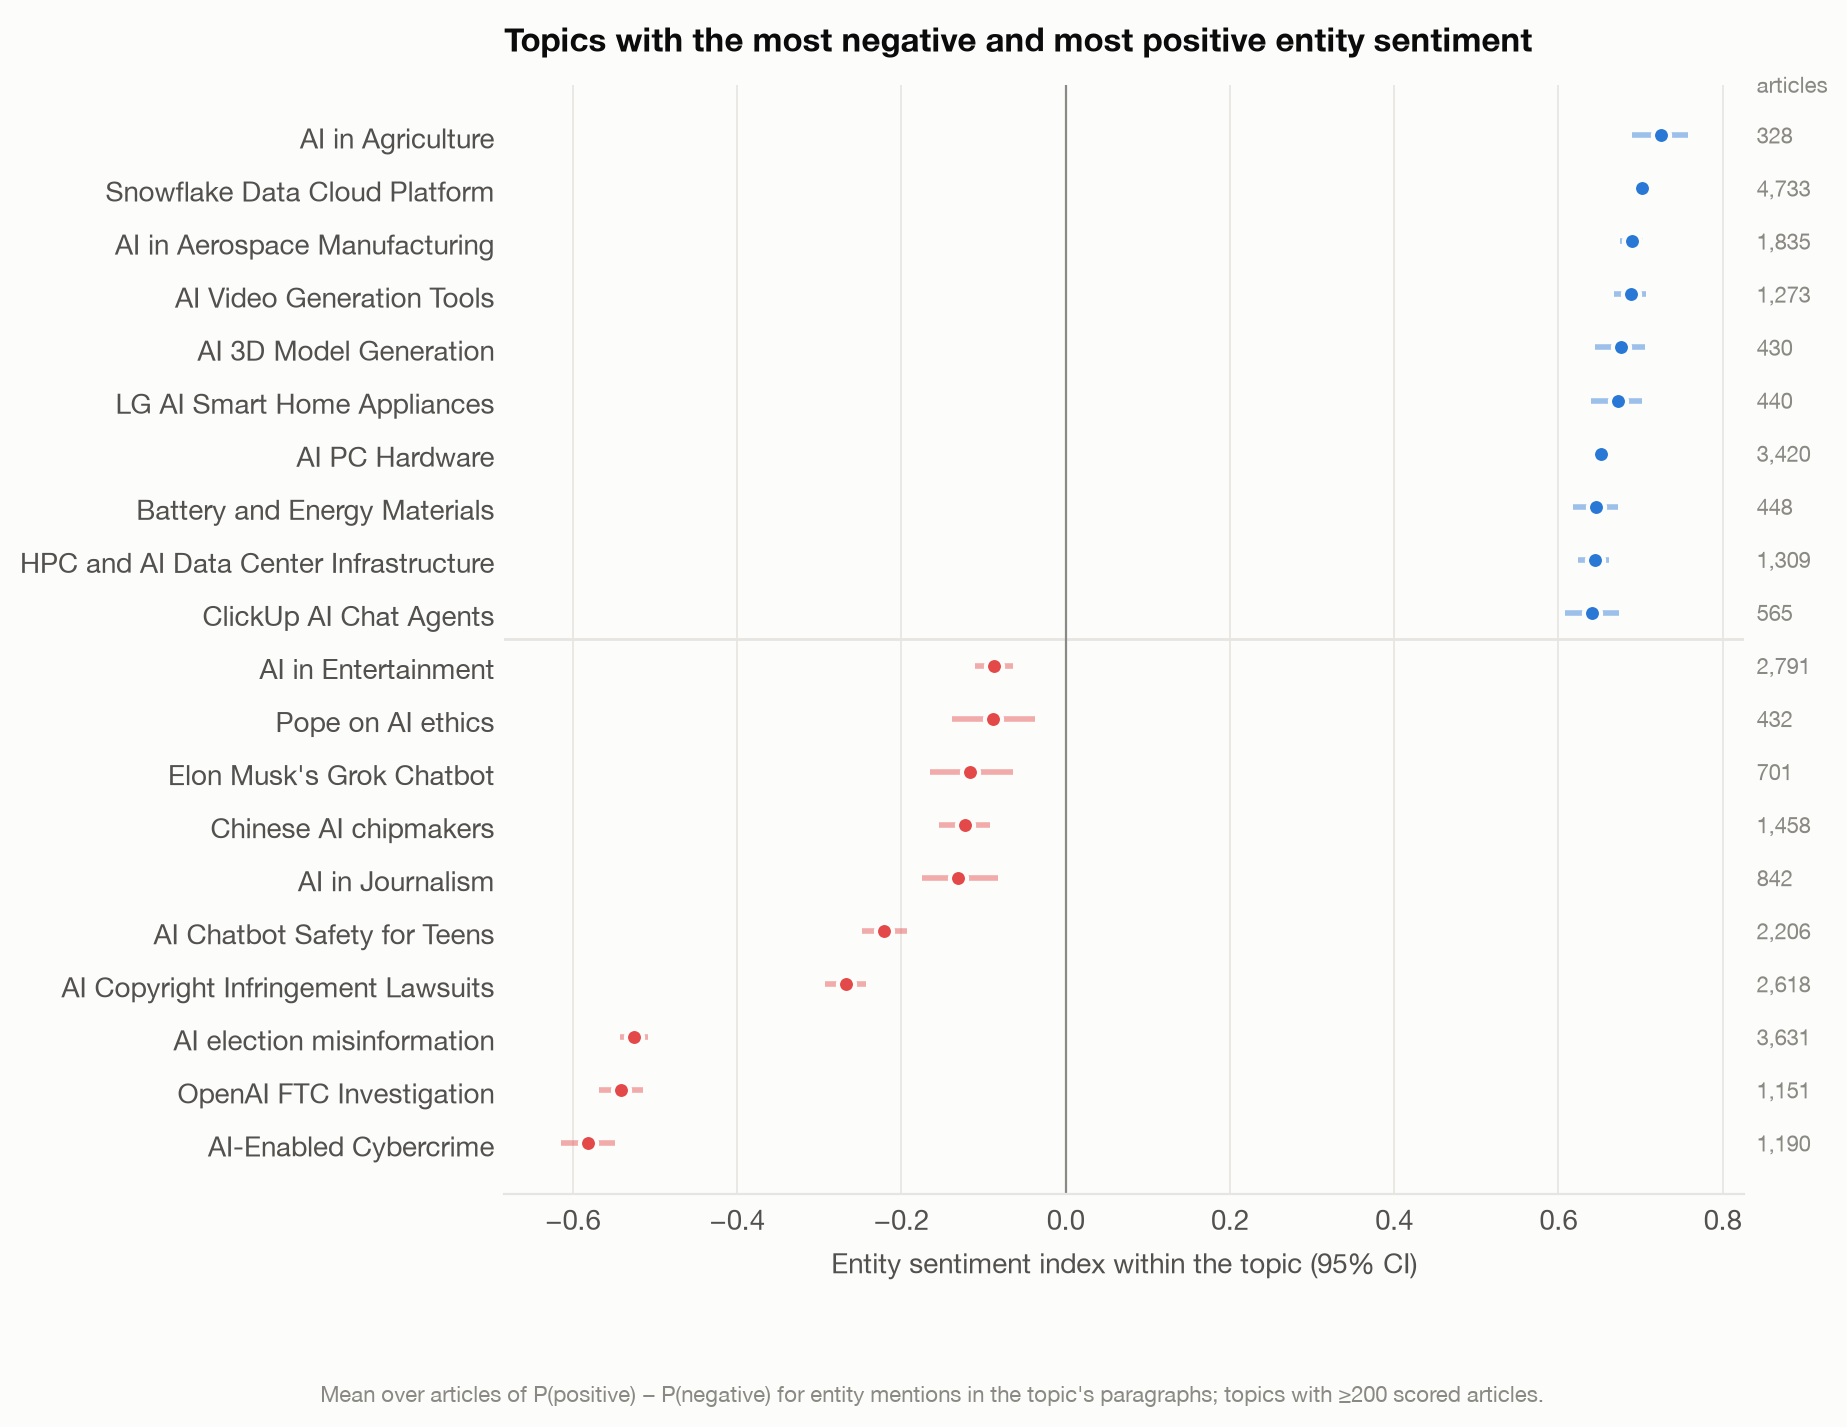

In [15]:
fig("f15_topic_sentiment.png")

Sentiment over time: all articles by month, then by quarter for the five most-covered adopting sectors and the most-covered AI companies.

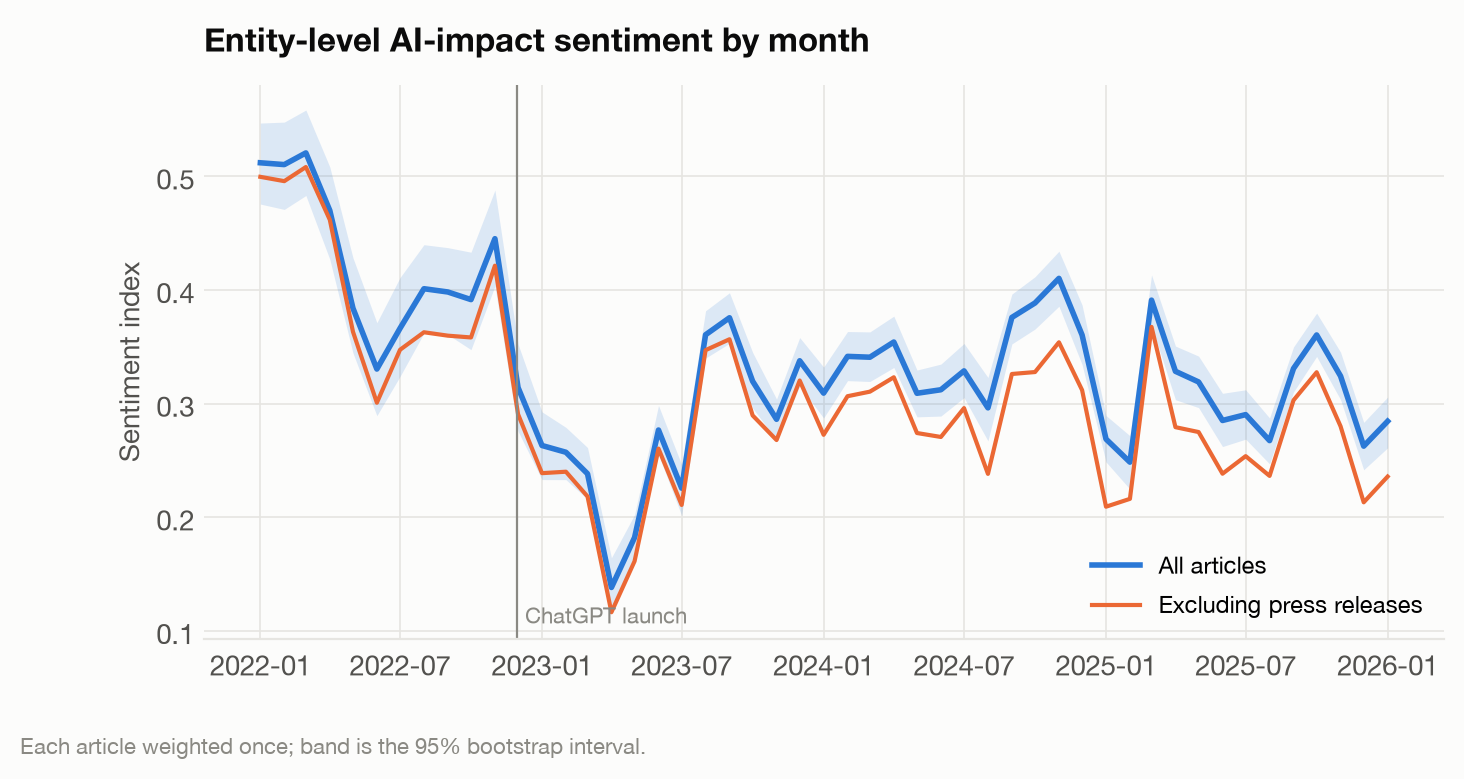

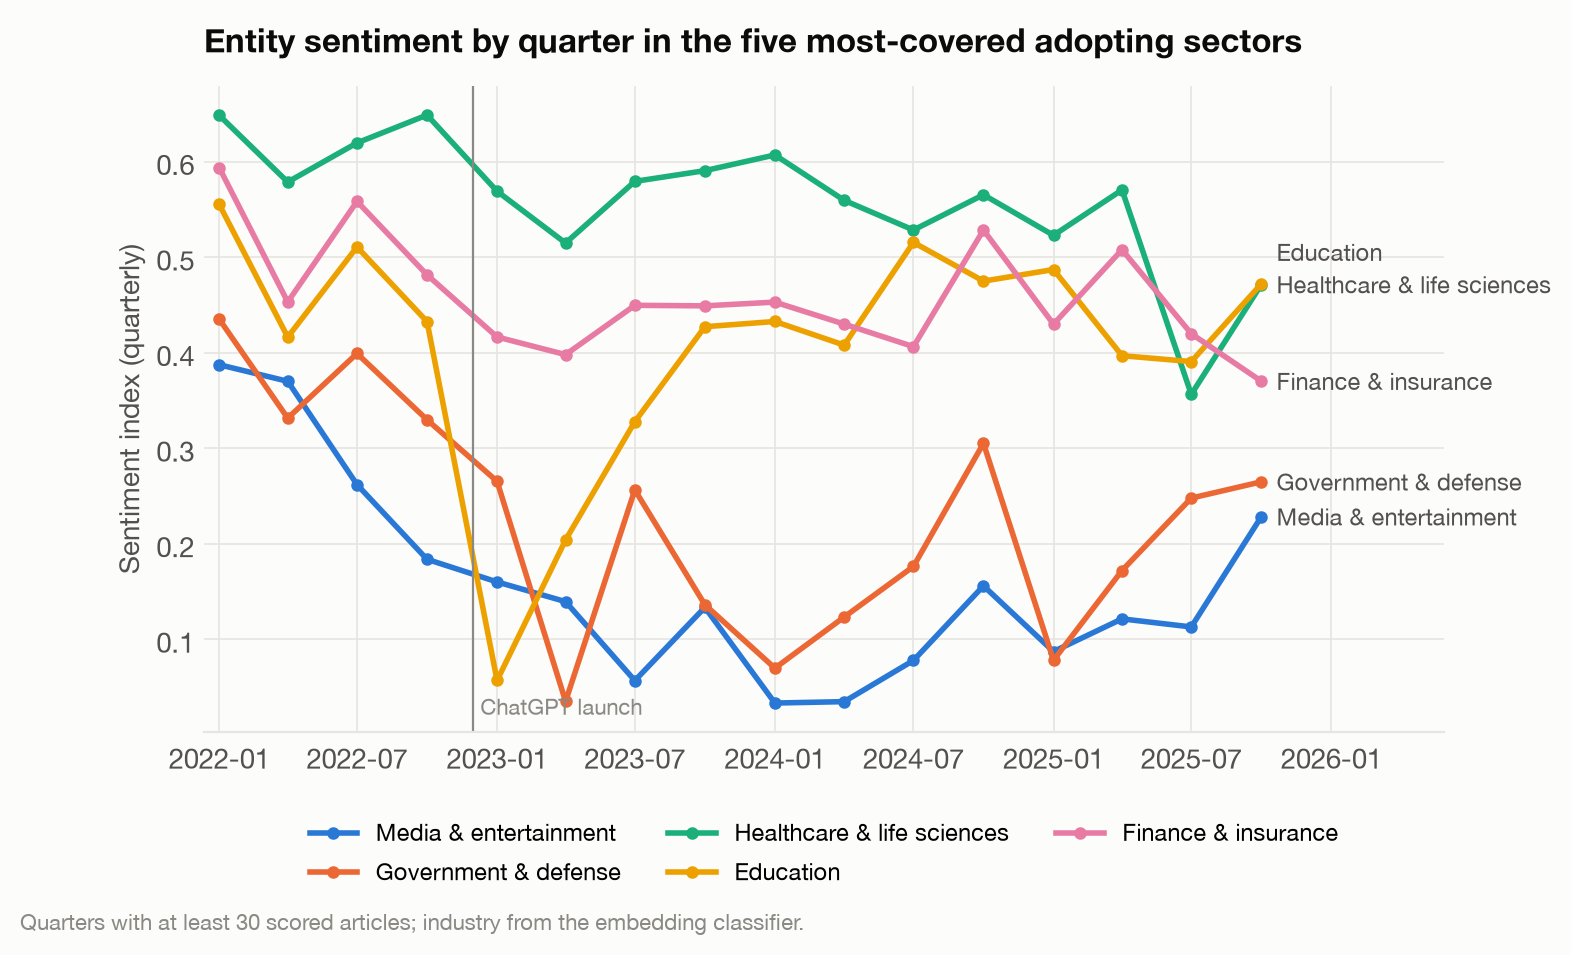

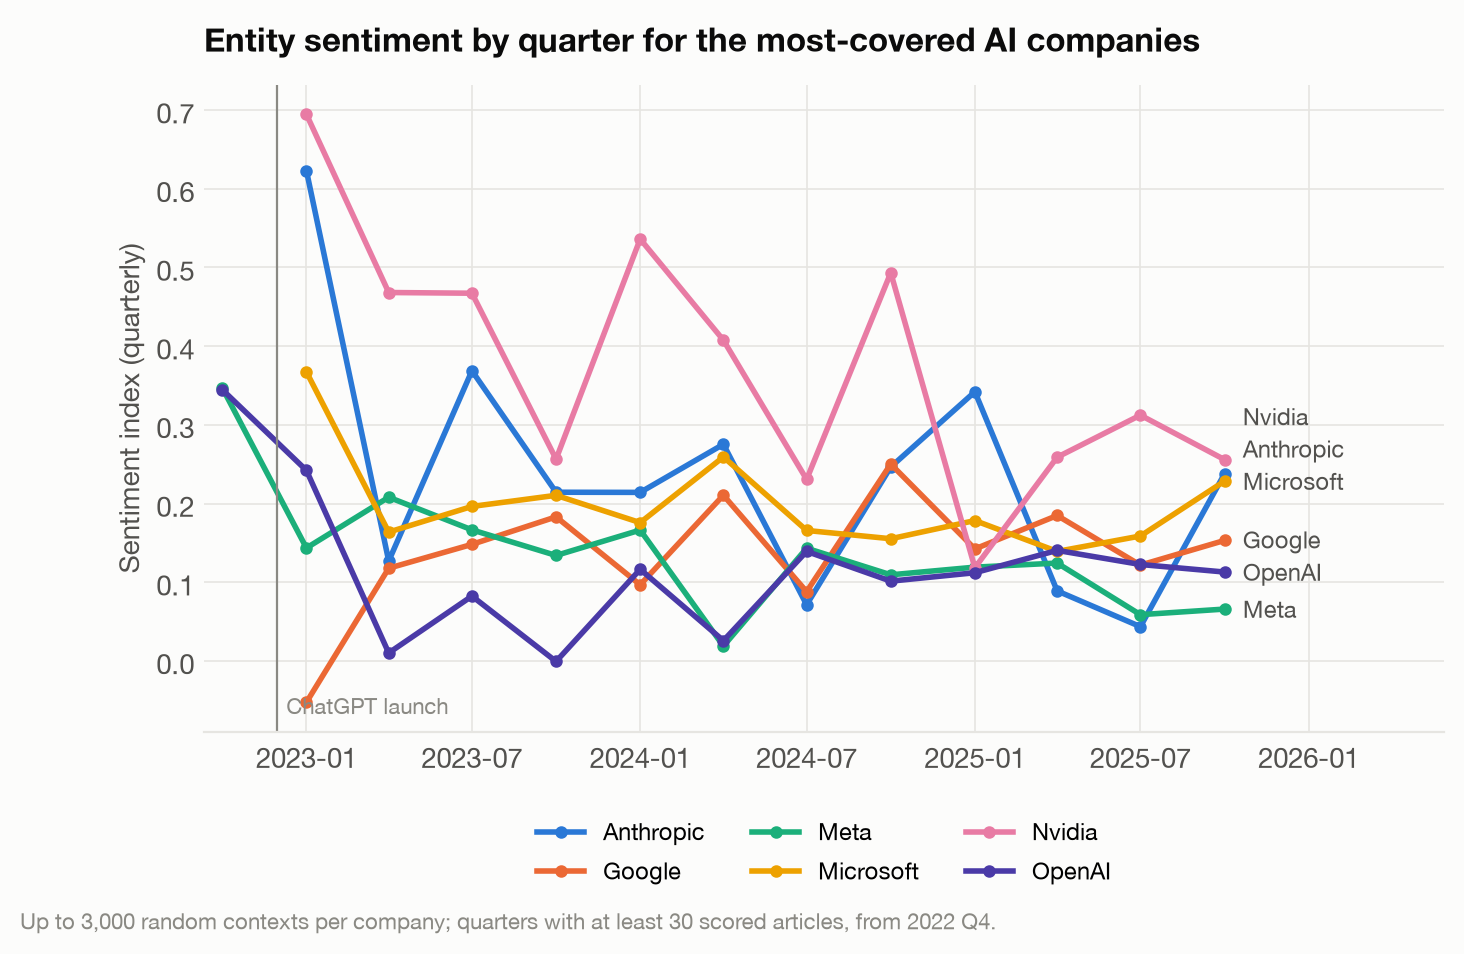

In [16]:
fig("f09_sentiment_trend.png"); fig("f17_sentiment_trend_industries.png"); fig("f18_sentiment_trend_companies.png")

In [17]:
table("industry_quarterly_sentiment.csv").pivot(index="quarter", columns="group", values="sentiment_index").round(2)

group,education,finance_insurance,government_defense,healthcare_life_sciences,media_entertainment
quarter,,,,,
2022Q1,0.56,0.59,0.44,0.65,0.39
2022Q2,0.42,0.45,0.33,0.58,0.37
2022Q3,0.51,0.56,0.40,0.62,0.26
2022Q4,0.43,0.48,0.33,0.65,0.18
2023Q1,0.06,0.42,0.27,0.57,0.16
2023Q2,0.20,0.40,0.04,0.51,0.14
2023Q3,0.33,0.45,0.26,0.58,0.06
2023Q4,0.43,0.45,0.14,0.59,0.13
2024Q1,0.43,0.45,0.07,0.61,0.03


## RQ3 — Adoption factors

Setback rate = setback / (deployed + setback) among adoption stories. These are associations in coverage, not causal effects.

In [18]:
fac = table("adoption_factors.csv")
fac[["factor", "share_enabler", "share_barrier", "n_adoption_docs_citing_barrier", "setback_rate_when_barrier",
     "setback_rate_when_barrier_lo", "setback_rate_when_barrier_hi", "setback_rate_all_adoption"]].round(3)

,factor,share_enabler,share_barrier,n_adoption_docs_citing_barrier,setback_rate_when_barrier,setback_rate_when_barrier_lo,setback_rate_when_barrier_hi,setback_rate_all_adoption
0,trust_safety,0.068,0.208,1093,0.529,0.498,0.558,0.255
1,regulation_policy,0.064,0.119,547,0.669,0.633,0.708,0.255
2,talent_skills,0.080,0.040,177,0.164,0.115,0.227,0.255
3,cost_roi,0.056,0.038,159,0.233,0.171,0.305,0.255
4,data,0.072,0.038,160,0.456,0.382,0.535,0.255
5,compute_infrastructure,0.064,0.028,94,0.266,0.181,0.360,0.255
6,leadership_strategy,0.104,0.020,87,0.609,0.506,0.710,0.255
7,integration,0.054,0.019,96,0.167,0.096,0.242,0.255
8,partnerships,0.181,0.003,11,NaN,NaN,NaN,0.255


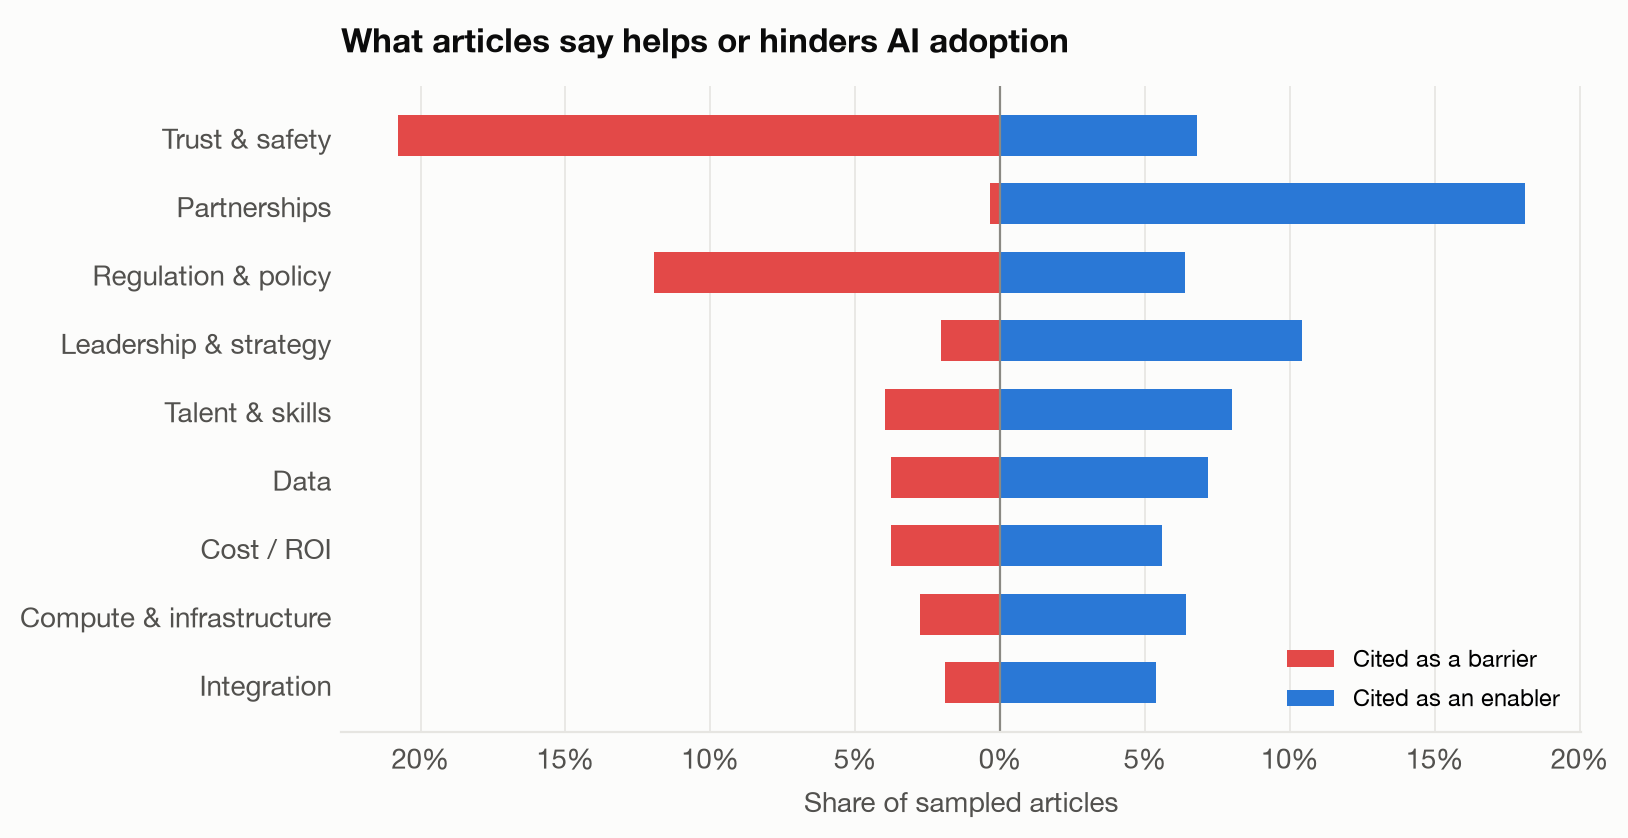

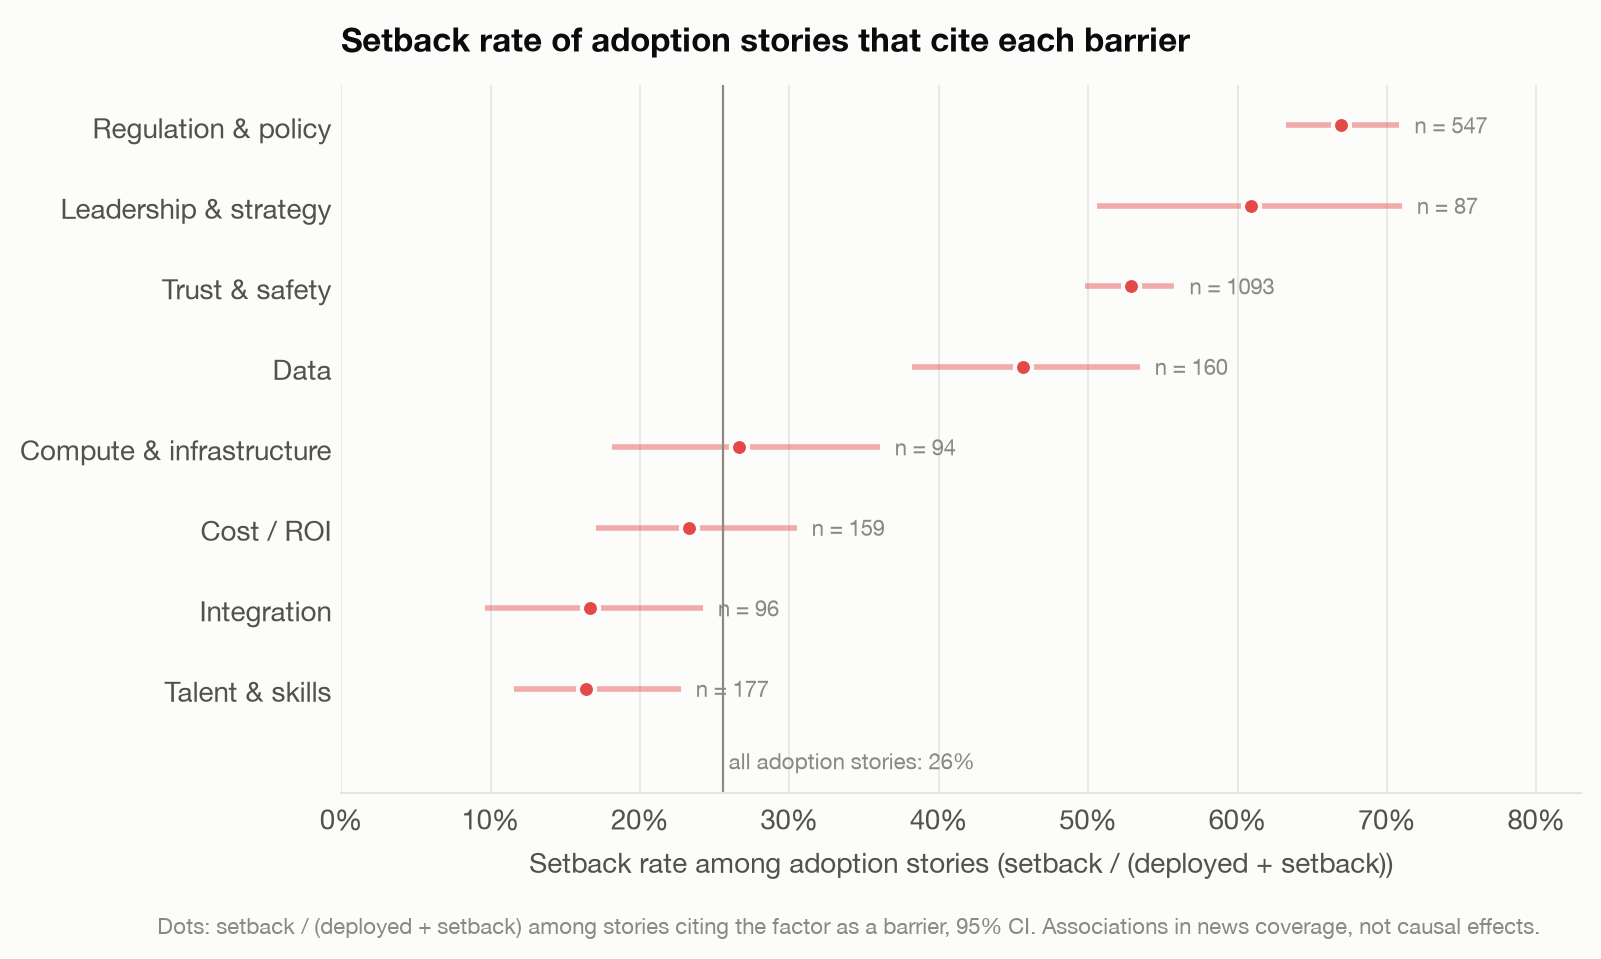

In [19]:
fig("f10_adoption_factors.png"); fig("f11_setback_rates.png")

In [20]:
table("adoption_outcomes_by_industry.csv").filter(regex="industry|n_docs|share_[a-z_]+$").round(3)

,industry,n_docs_sample,share_deployed,share_deployed_lo,share_deployed_hi,share_pilot_or_plan,share_pilot_or_plan_lo,share_pilot_or_plan_hi,share_setback,share_setback_lo,share_setback_hi,share_product_launch,share_product_launch_lo,share_product_launch_hi,share_none,share_none_lo,share_none_hi
0,software_it,5277,0.102,0.094,0.110,0.097,0.089,0.106,0.059,0.053,0.066,0.507,0.495,0.521,0.235,0.224,0.246
1,semiconductors_hardware,893,0.078,0.062,0.097,0.077,0.060,0.095,0.024,0.014,0.034,0.514,0.480,0.546,0.307,0.277,0.335
2,telecom,166,0.247,0.178,0.311,0.283,0.214,0.352,0.030,0.006,0.059,0.283,0.216,0.352,0.157,0.103,0.216
3,finance_insurance,678,0.254,0.225,0.288,0.121,0.096,0.147,0.031,0.019,0.044,0.273,0.241,0.310,0.322,0.288,0.355
4,healthcare_life_sciences,996,0.249,0.222,0.275,0.196,0.172,0.220,0.020,0.012,0.029,0.274,0.246,0.302,0.261,0.236,0.288
5,education,694,0.180,0.153,0.211,0.246,0.216,0.278,0.073,0.055,0.093,0.239,0.209,0.271,0.261,0.228,0.297
6,media_entertainment,1680,0.199,0.180,0.217,0.074,0.062,0.087,0.104,0.089,0.118,0.336,0.313,0.356,0.288,0.266,0.308
7,retail_consumer,518,0.295,0.259,0.335,0.091,0.065,0.117,0.031,0.017,0.047,0.461,0.418,0.502,0.122,0.093,0.151
8,manufacturing_industrial,183,0.131,0.087,0.181,0.131,0.083,0.183,0.005,0.000,0.017,0.459,0.385,0.529,0.273,0.214,0.341
9,transportation_automotive,325,0.277,0.231,0.324,0.200,0.158,0.244,0.028,0.012,0.048,0.243,0.197,0.293,0.252,0.205,0.299
